In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install lightning


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 21.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.9/801.9 kB 24.8 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manyl

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

In [ ]:
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.20.3
    Uninstalling huggingface-hub-0.20.3:
      Successfully uninstalled huggingface-hub-0.20.3


In [ ]:
!pip install Rouge

In [ ]:
from rouge import Rouge

In [ ]:
import transformers
from transformers import T5Tokenizer, T5ForConditionalGeneration, AutoTokenizer, AutoModel
from transformers import PegasusForConditionalGeneration, PegasusTokenizer, BartForConditionalGeneration
from transformers import DataCollatorForSeq2Seq, AdamW, get_linear_schedule_with_warmup
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer
from transformers import create_optimizer, AdamWeightDecay
from transformers import pipeline
import datasets
from datasets import Dataset, DatasetDict
#from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
device

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/news_summary.csv", encoding="latin-1")
df.head()

,author,date,headlines,read_more,text,ctext
0,Chhavi Tyagi,"03 Aug 2017,Thursday",Daman & Diu revokes mandatory Rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,The Administration of Union Territory Daman an...,The Daman and Diu administration on Wednesday ...
1,Daisy Mowke,"03 Aug 2017,Thursday",Malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,Malaika Arora slammed an Instagram user who tr...,"From her special numbers to TV?appearances, Bo..."
2,Arshiya Chopra,"03 Aug 2017,Thursday",'Virgin' now corrected to 'Unmarried' in IGIMS...,http://www.hindustantimes.com/patna/bihar-igim...,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Sumedha Sehra,"03 Aug 2017,Thursday",Aaj aapne pakad liya: LeT man Dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",Hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,Hotels in Maharashtra will train their staff t...,Hotels in Mumbai and other Indian cities are t...


In [ ]:
# drop na
df = df.dropna()
df.describe()

,author,date,headlines,read_more,text,ctext
count,4396,4396,4396,4396,4396,4396
unique,45,240,4396,4344,4396,4341
top,Chhavi Tyagi,"19 Jul 2017,Wednesday",Daman & Diu revokes mandatory Rakshabandhan in...,http://indiatoday.intoday.in/story/assembly-el...,The Administration of Union Territory Daman an...,AAJ TAK LIVE TV WITH LIVE ELECTION RESULTS I c...
freq,546,76,1,13,1,13


In [ ]:
# Converting to lowercase
df['ctext'] = df['ctext'].apply(str.lower)
df['text'] = df['text'].apply(str.lower)
df['headlines'] = df['headlines'].apply(str.lower)
df.head()


,author,date,headlines,read_more,text,ctext
0,Chhavi Tyagi,"03 Aug 2017,Thursday",daman & diu revokes mandatory rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,the administration of union territory daman an...,the daman and diu administration on wednesday ...
1,Daisy Mowke,"03 Aug 2017,Thursday",malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,malaika arora slammed an instagram user who tr...,"from her special numbers to tv?appearances, bo..."
2,Arshiya Chopra,"03 Aug 2017,Thursday",'virgin' now corrected to 'unmarried' in igims...,http://www.hindustantimes.com/patna/bihar-igim...,the indira gandhi institute of medical science...,the indira gandhi institute of medical science...
3,Sumedha Sehra,"03 Aug 2017,Thursday",aaj aapne pakad liya: let man dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,lashkar-e-taiba's kashmir commander abu dujana...,lashkar-e-taiba's kashmir commander abu dujana...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,hotels in maharashtra will train their staff t...,hotels in mumbai and other indian cities are t...


In [ ]:
df['headlines_length'] = [len(x.split()) for x in df.headlines]
df['text_length'] = [len(x.split()) for x in df.text]
df['ctext_length'] = [len(x.split()) for x in df.ctext]
df.head()

,author,date,headlines,read_more,text,ctext,headlines_length,text_length,ctext_length
0,Chhavi Tyagi,"03 Aug 2017,Thursday",daman & diu revokes mandatory rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,the administration of union territory daman an...,the daman and diu administration on wednesday ...,9,60,364
1,Daisy Mowke,"03 Aug 2017,Thursday",malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,malaika arora slammed an instagram user who tr...,"from her special numbers to tv?appearances, bo...",10,60,396
2,Arshiya Chopra,"03 Aug 2017,Thursday",'virgin' now corrected to 'unmarried' in igims...,http://www.hindustantimes.com/patna/bihar-igim...,the indira gandhi institute of medical science...,the indira gandhi institute of medical science...,8,60,335
3,Sumedha Sehra,"03 Aug 2017,Thursday",aaj aapne pakad liya: let man dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,lashkar-e-taiba's kashmir commander abu dujana...,lashkar-e-taiba's kashmir commander abu dujana...,10,60,404
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,hotels in maharashtra will train their staff t...,hotels in mumbai and other indian cities are t...,11,60,526


In [ ]:
df = df[df['ctext_length'] >= df['text_length']]
df.describe()

,headlines_length,text_length,ctext_length
count,4274.000000,4274.000000,4274.000000
mean,9.300889,58.299719,351.740056
std,1.407168,2.314246,358.884472
min,4.000000,44.000000,50.000000
25%,8.000000,57.000000,193.000000
50%,9.000000,59.000000,288.000000
75%,10.000000,60.000000,416.000000
max,14.000000,62.000000,12202.000000


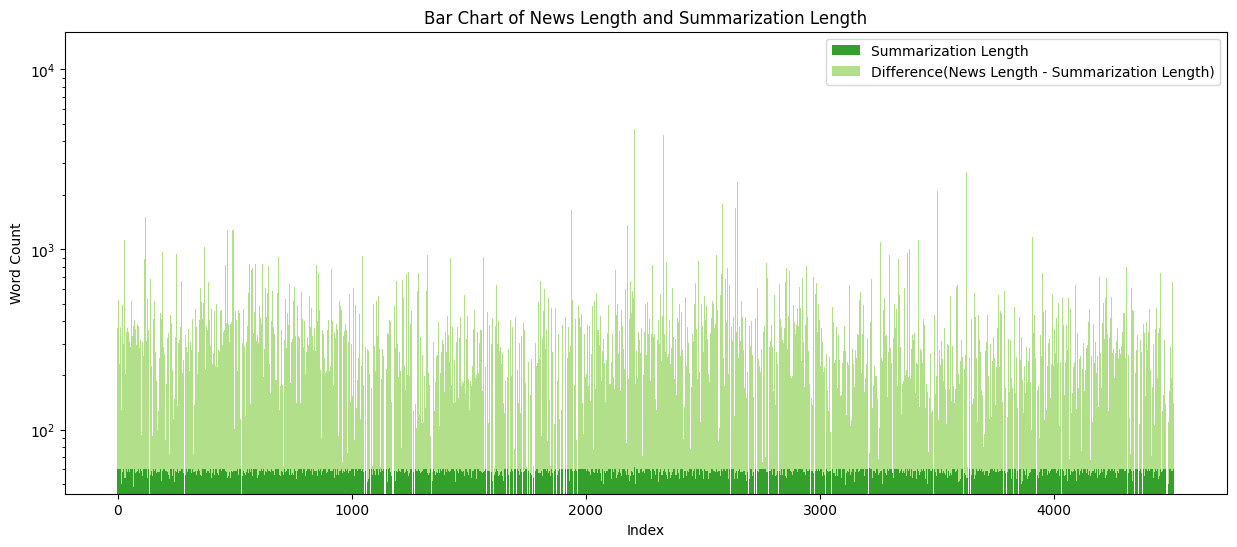

In [ ]:
df['diff'] = df['ctext_length'] - df['text_length']
#sns.set(style="whitegrid")
color1 = sns.color_palette("Paired")[3]
color2 = sns.color_palette("Paired")[2]

plt.figure(figsize=(15, 6))
bar1 = plt.bar(df.index, df['text_length'], color=color1, label='Summarization Length', width=1.0)
bar2 = plt.bar(df.index, df['diff'], bottom=df['text_length'], color=color2, label='Difference(News Length - Summarization Length)', width=1.0)

plt.xlabel('Index')
plt.ylabel('Word Count')
plt.title('Bar Chart of News Length and Summarization Length')
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
df['news'] = df['headlines'] + '. ' + df['ctext']
df.rename(columns={"text": "summary"}, inplace = True)
df = df.drop(columns=['headlines', 'ctext'])
df.head()

,author,date,read_more,summary,headlines_length,text_length,ctext_length,news
0,Chhavi Tyagi,"03 Aug 2017,Thursday",http://www.hindustantimes.com/india-news/raksh...,the administration of union territory daman an...,9,60,364,daman & diu revokes mandatory rakshabandhan in...
1,Daisy Mowke,"03 Aug 2017,Thursday",http://www.hindustantimes.com/bollywood/malaik...,malaika arora slammed an instagram user who tr...,10,60,396,malaika slams user who trolled her for 'divorc...
2,Arshiya Chopra,"03 Aug 2017,Thursday",http://www.hindustantimes.com/patna/bihar-igim...,the indira gandhi institute of medical science...,8,60,335,'virgin' now corrected to 'unmarried' in igims...
3,Sumedha Sehra,"03 Aug 2017,Thursday",http://indiatoday.intoday.in/story/abu-dujana-...,lashkar-e-taiba's kashmir commander abu dujana...,10,60,404,aaj aapne pakad liya: let man dujana before be...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",http://indiatoday.intoday.in/story/sex-traffic...,hotels in maharashtra will train their staff t...,11,60,526,hotel staff to get training to spot signs of s...


In [ ]:
prefix = 'summarize: '
df['news'] = prefix + df['news']
df.head()

,author,date,read_more,summary,headlines_length,text_length,ctext_length,news
0,Chhavi Tyagi,"03 Aug 2017,Thursday",http://www.hindustantimes.com/india-news/raksh...,the administration of union territory daman an...,9,60,364,summarize: daman & diu revokes mandatory raksh...
1,Daisy Mowke,"03 Aug 2017,Thursday",http://www.hindustantimes.com/bollywood/malaik...,malaika arora slammed an instagram user who tr...,10,60,396,summarize: malaika slams user who trolled her ...
2,Arshiya Chopra,"03 Aug 2017,Thursday",http://www.hindustantimes.com/patna/bihar-igim...,the indira gandhi institute of medical science...,8,60,335,summarize: 'virgin' now corrected to 'unmarrie...
3,Sumedha Sehra,"03 Aug 2017,Thursday",http://indiatoday.intoday.in/story/abu-dujana-...,lashkar-e-taiba's kashmir commander abu dujana...,10,60,404,summarize: aaj aapne pakad liya: let man dujan...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",http://indiatoday.intoday.in/story/sex-traffic...,hotels in maharashtra will train their staff t...,11,60,526,summarize: hotel staff to get training to spot...


In [ ]:
# Converting the pandas dataset to huggingface dataset
# first split the train and test set
train_df, test_df = train_test_split(df, test_size=0.01, shuffle=True)
print("train and val shape:", train_df.shape, "test shape:",test_df.shape)
# save for every model inference
global_train_df = train_df
global_test_df = test_df
train_df = datasets.Dataset.from_pandas(train_df)
train_df = train_df.remove_columns(["__index_level_0__"])
# split train into train and val
train_df = train_df.train_test_split(test_size=0.2, shuffle=True)
train_df["train"][0]

train and val shape: (4231, 8) test shape: (43, 8)


{'author': 'Sonu Kumari',
 'date': '24 Jul 2017,Monday',
 'read_more': 'http://www.hindustantimes.com/gurgaon/gurgaon-aloo-gang-member-held-with-illegal-arms-in-rewari/story-RfkolBdeGnjaGNbFtAitVL.html?utm_source=inshorts&utm_medium=referral&utm_campaign=fullarticle ',
 'summary': "the gurugram police on thursday arrested a man belonging to the rewari-based 'aloo' gang for allegedly possessing illegal arms and recovered two country-made pistols and 12 live cartridges. he was reportedly in sohna to murder a member of the rival 'jhota' gang. the 'aloo' gang is wanted for several cases of murder and attempted murder.",
 'headlines_length': 9,
 'text_length': 55,
 'ctext_length': 300,
 'news': "summarize: 'aloo' gang member arrested with illegal arms in gurugram. a man arrested by the city police?s crime branch on thursday night for allegedly possessing illegal arms has turned out to be a member of rewari?s aloo gang.on thursday, the crime team of sohna police was patrolling the area near 

In [ ]:
train_dataset, val_dataset = train_df["train"], train_df["test"]

In [ ]:
train_val_test_dataset = DatasetDict({
    'train': train_dataset,
    'val': val_dataset
})

In [ ]:
# Fitting into dataset dict
train_val_test_dataset = DatasetDict({
    'train': train_df["train"],
    'val': train_df['test']})

print(type(train_val_test_dataset))
train_val_test_dataset

<class 'datasets.dataset_dict.DatasetDict'>


DatasetDict({
    train: Dataset({
        features: ['author', 'date', 'read_more', 'summary', 'headlines_length', 'text_length', 'ctext_length', 'news'],
        num_rows: 3384
    })
    val: Dataset({
        features: ['author', 'date', 'read_more', 'summary', 'headlines_length', 'text_length', 'ctext_length', 'news'],
        num_rows: 847
    })
})

In [ ]:
# tokenize the data
model_name = "t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [ ]:
def prepare_dataset(data):
    inputs = data["news"]
    targets = data["summary"]

    # Tokenize input and target text
    inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length", return_tensors="pt")
    targets = tokenizer(targets, max_length=128, truncation=True, padding="max_length", return_tensors="pt")

    # Modify the inputs to include labels
    inputs["labels"] = targets["input_ids"]

    return inputs

In [ ]:
tokenized_data = train_val_test_dataset.map(prepare_dataset, batched=True)


Map:   0%|          | 0/3384 [00:00<?, ? examples/s]

Map:   0%|          | 0/847 [00:00<?, ? examples/s]

In [ ]:
tokenized_data["train"]

Dataset({
    features: ['author', 'date', 'read_more', 'summary', 'headlines_length', 'text_length', 'ctext_length', 'news', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 3384
})

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model_name)


In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    result = Rouge().get_scores(decoded_preds, decoded_labels, avg=True, ignore_empty=True)

    return result

In [ ]:
# prepare the model
T5model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

In [ ]:
# set up hyper-parameters
training_args = Seq2SeqTrainingArguments(
    output_dir="t5-news",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=4,
    predict_with_generate=True,
    fp16=True,
    report_to="none"
)

In [ ]:
# setup trainer
trainer = Seq2SeqTrainer(
    model = T5model,
    args = training_args,
    train_dataset = tokenized_data["train"],
    eval_dataset = tokenized_data["val"],
    tokenizer = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics
)

Using amp half precision backend


In [ ]:
trainer.train()

The following columns in the training set  don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: summary, author, news, read_more, date, ctext_length, headlines_length, text_length.
***** Running training *****
  Num examples = 3384
  Num Epochs = 4
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 848


Epoch,Training Loss,Validation Loss,Rouge-1,Rouge-2,Rouge-l
1,No log,1.020125,"{'r': 0.14061044550107882, 'p': 0.6332330429019207, 'f': 0.22755007463658267}","{'r': 0.059475442331841606, 'p': 0.34535830878330004, 'f': 0.10032632644548468}","{'r': 0.1301308480100187, 'p': 0.5879800909241529, 'f': 0.21070563881157428}"
2,No log,0.993121,"{'r': 0.14555673054945928, 'p': 0.6547240067540734, 'f': 0.23554936799341303}","{'r': 0.06457167697425865, 'p': 0.37376221347156807, 'f': 0.10889854779194114}","{'r': 0.1349596275179939, 'p': 0.6086923923564629, 'f': 0.218511200821269}"
3,1.264800,0.983686,"{'r': 0.14804048602569211, 'p': 0.6628448171580287, 'f': 0.23946220478489283}","{'r': 0.06651014258114658, 'p': 0.38298434854879726, 'f': 0.11211819087688596}","{'r': 0.13741314758049528, 'p': 0.6163241257217538, 'f': 0.222346612676058}"
4,1.264800,0.981565,"{'r': 0.1490612594403201, 'p': 0.6680833657936881, 'f': 0.24114283071688414}","{'r': 0.06740373732228352, 'p': 0.38825946173418213, 'f': 0.11362829126132609}","{'r': 0.13838735063421015, 'p': 0.6213173213471114, 'f': 0.22395473855745207}"


The following columns in the evaluation set  don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: summary, author, news, read_more, date, ctext_length, headlines_length, text_length.
***** Running Evaluation *****
  Num examples = 847
  Batch size = 16
The following columns in the evaluation set  don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: summary, author, news, read_more, date, ctext_length, headlines_length, text_length.
***** Running Evaluation *****
  Num examples = 847
  Batch size = 16
Saving model checkpoint to t5-news/checkpoint-500
Configuration saved in t5-news/checkpoint-500/config.json
Model weights saved in t5-news/checkpoint-500/pytorch_model.bin
tokenizer config file saved in t5-news/checkpoint-500/tokenizer_config.json
Special tokens file saved in t5-news/checkpoint-500/special_tokens_map.json
Copy vocab file to t5-news/checkpoint-500/spiece.model
The following columns i

TrainOutput(global_step=848, training_loss=1.167603294804411, metrics={'train_runtime': 456.829, 'train_samples_per_second': 29.63, 'train_steps_per_second': 1.856, 'total_flos': 8242854006620160.0, 'train_loss': 1.167603294804411, 'epoch': 4.0})

In [ ]:
trainer.train()

The following columns in the training set  don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: date, news, summary, ctext_length, author, read_more, text_length, headlines_length.
***** Running training *****
  Num examples = 3384
  Num Epochs = 4
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 848


OutOfMemoryError: CUDA out of memory. Tried to allocate 24.00 MiB. GPU 0 has a total capacity of 15.77 GiB of which 16.38 MiB is free. Process 85425 has 15.75 GiB memory in use. Of the allocated memory 15.16 GiB is allocated by PyTorch, and 219.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# save the model
model_path = "/content/drive/MyDrive/Models/t5-news"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

In [ ]:
model_path = "/content/drive/MyDrive/Models/t5-news"

In [ ]:
t5_model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

In [ ]:
#for i in range(len(test_df['news']):
for i in range(5):
    print("original_news: ",test_df['news'].iloc[i])
    summarizer = pipeline("summarization", model = t5_model,tokenizer = tokenizer, max_length = 100)
    summary = summarizer(test_df['news'].iloc[i])
    print(summary[0])
    print()

original_news:  summarize: pm modi reduced gandhi to his spectacles: bapu's grandson. in a candid conversation with india today consulting editor rajdeep sardesai during a session at the india today conclave south 2017 on the second day of the event, gopalkrishna gandhi, mahatma gandhi's grandson, said, "the present prime minister narendra modi has reduced the name of mahatma gandhi to his spectacles.""but the question is why does he need those spectacles? he needs it because there is room for veracity," gandhi said.bjp speaks about sardar patel because he also stood for veracity, gopalkrishna gandhi said.praise for kerjiwal, kanhaiyamaking a nuanced comment about the need for idealism-based politics, gopalkrishna gandhi said, "there is great hope in india for non-cluster, non-family, non-right-wing politics. right-wingism is about being on the side of majority (ignoring others).""anna hazare and arvind kejriwal brought a fresh hope on jantar matar few years ago. i don't know how will 

In [ ]:
summary = summarizer("Guava (/ˈɡwɑːvə/ GWAH-və)[1] is a common tropical fruit cultivated in many tropical and subtropical regions.[2] The common guava Psidium guajava (lemon guava, apple guava) is a small tree in the myrtle family (Myrtaceae), native to Mexico, Central America, the Caribbean and northern South America.[2] The name guava is also given to some other species in the genus Psidium such as strawberry guava (Psidium cattleyanum) and to the pineapple guava, Feijoa sellowiana. In 2019, 55 million tonnes of guavas were produced worldwide, led by India with 45% of the total. Botanically, guavas are berries. Apple guava flower White guava Types The most frequently eaten species, and the one often simply referred to as \"the guava\", is the apple guava (Psidium guajava). Guavas are typical Myrtoideae, with tough dark heavy leaves that are opposite, simple, elliptic to ovate, and 5–15 centimetres (2–6 in) long. The flowers are white, with five petals and numerous stamens. The fruits are many-seeded berries.[3] Etymology The term guava appears to have been in use since the mid-16th century.[4] The name derived from the Taíno,[5] a language of the Arawaks as guayabo for guava tree via the Spanish for guayaba.[4] It has been adapted in many European and Asian languages, having a similar form.[2]")
print(summary[0])
print()

{'summary_text': 'the guava (/wv/ GWAH-v) is a common tropical fruit cultivated in many tropical and subtropical regions. the apple guajava (psidium guiajava) is native to Mexico, Central America, the Caribbean and northern South America. in 2019, 55 million tonnes were produced worldwide, led by India with 45% of the total.'}



In [ ]:
with open('/content/testing.txt', 'r') as file:
    # Read the entire content of the file
    file_content = file.read()

    # Print the content
    print(file_content)

“Laying Plans
     [Ts`ao Kung, in defining the meaning of the Chinese for the
title of this chapter, says it refers to the deliberations in the
temple selected by the general for his temporary use, or as we
should say, in his tent.  See. ss. 26.]
     1.  Sun Tzu said:  The art of war is of vital importance to
the State.
     2.  It is a matter of life and death, a road either to
safety or to ruin.  Hence it is a subject of inquiry which can on
no account be neglected.
     3.  The art of war, then, is governed by five constant
factors,  to be taken into account in one's deliberations,  when
seeking to determine the conditions obtaining in the field.
     4.  These are:  (1) The Moral Law; (2) Heaven;  (3)  Earth;
(4) The Commander; (5) Method and discipline.
     [It appears from what follows that Sun Tzu means by  "Moral
Law" a principle of harmony,”

“not unlike the Tao of Lao Tzu in its
moral aspect.  One might be tempted to render it by  "morale,"
were it not considered as an att

In [ ]:
summary = summarizer(file_content)
print(summary)


[{'summary_text': '"when you lay down a law, see that it is not disobeyed; if it is disobedient, the offender must be put to death," he said. "the art of war, then, is governed by five constant factors, to be taken into account in one\'s deliberations, when seeking to determine the conditions obtaining in the field." he added, "without constant practice, the people will be nervous and unde'}]



# Pegasus

In [ ]:
# Free up memory
torch.cuda.empty_cache()

In [ ]:
# tokenize the data
model_name = "google/pegasus-large"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast = False)
tokenized_data = train_val_test_dataset.map(prepare_dataset, batched=True)

Downloading:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/3.02k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Map:   0%|          | 0/3384 [00:00<?, ? examples/s]

Map:   0%|          | 0/847 [00:00<?, ? examples/s]

In [ ]:
# Padding
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model_name)

In [ ]:
# model
PEGASUSmodel = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

Downloading:   0%|          | 0.00/2.12G [00:00<?, ?B/s]

In [ ]:
# set up hyper-parameters
training_args = Seq2SeqTrainingArguments(
    output_dir="pegasus-news",
    evaluation_strategy="epoch",
    learning_rate=1e-6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=False, # FP16 not supported for PEGASUS: https://huggingface.co/docs/transformers/model_doc/pegasus#checkpoints
    report_to="none"
)

In [ ]:
# setup trainer
trainer = Seq2SeqTrainer(
    model = PEGASUSmodel,
    args = training_args,
    train_dataset = tokenized_data["train"],
    eval_dataset = tokenized_data["val"],
    tokenizer = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics
)

In [ ]:
trainer.train()

The following columns in the training set  don't have a corresponding argument in `PegasusForConditionalGeneration.forward` and have been ignored: headlines_length, date, news, text_length, summary, read_more, author, ctext_length.
***** Running training *****
  Num examples = 3384
  Num Epochs = 3
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 1269


Epoch,Training Loss,Validation Loss,Rouge-1,Rouge-2,Rouge-l
1,No log,5.670645,"{'r': 0.41741983676760125, 'p': 0.3387732615427187, 'f': 0.35476730758800307}","{'r': 0.18062750552971193, 'p': 0.1462354376718173, 'f': 0.14907989374859248}","{'r': 0.3690772058955867, 'p': 0.29905749604501186, 'f': 0.3132745463100563}"


The following columns in the evaluation set  don't have a corresponding argument in `PegasusForConditionalGeneration.forward` and have been ignored: headlines_length, date, news, text_length, summary, read_more, author, ctext_length.
***** Running Evaluation *****
  Num examples = 847
  Batch size = 8
Saving model checkpoint to pegasus-news/checkpoint-500
Configuration saved in pegasus-news/checkpoint-500/config.json
Model weights saved in pegasus-news/checkpoint-500/pytorch_model.bin
tokenizer config file saved in pegasus-news/checkpoint-500/tokenizer_config.json
Special tokens file saved in pegasus-news/checkpoint-500/special_tokens_map.json
The following columns in the evaluation set  don't have a corresponding argument in `PegasusForConditionalGeneration.forward` and have been ignored: headlines_length, date, news, text_length, summary, read_more, author, ctext_length.
***** Running Evaluation *****
  Num examples = 847
  Batch size = 8


Epoch,Training Loss,Validation Loss,Rouge-1,Rouge-2,Rouge-l
1,No log,5.670645,"{'r': 0.41741983676760125, 'p': 0.3387732615427187, 'f': 0.35476730758800307}","{'r': 0.18062750552971193, 'p': 0.1462354376718173, 'f': 0.14907989374859248}","{'r': 0.3690772058955867, 'p': 0.29905749604501186, 'f': 0.3132745463100563}"
2,6.295200,5.453112,"{'r': 0.4189151784233032, 'p': 0.33517602888423614, 'f': 0.353762327442429}","{'r': 0.18147657855721616, 'p': 0.14418538766391295, 'f': 0.14845565880366202}","{'r': 0.3704657783155473, 'p': 0.2959463727972444, 'f': 0.31243545318648186}"
3,5.817400,5.404049,"{'r': 0.42068022246709497, 'p': 0.33548046972647944, 'f': 0.35442332330551224}","{'r': 0.1841145053831453, 'p': 0.14490903548633255, 'f': 0.14964654178575099}","{'r': 0.3722239828736071, 'p': 0.29622921554609666, 'f': 0.31310985751800896}"


Saving model checkpoint to pegasus-news/checkpoint-1000
Configuration saved in pegasus-news/checkpoint-1000/config.json
Model weights saved in pegasus-news/checkpoint-1000/pytorch_model.bin
tokenizer config file saved in pegasus-news/checkpoint-1000/tokenizer_config.json
Special tokens file saved in pegasus-news/checkpoint-1000/special_tokens_map.json
The following columns in the evaluation set  don't have a corresponding argument in `PegasusForConditionalGeneration.forward` and have been ignored: headlines_length, date, news, text_length, summary, read_more, author, ctext_length.
***** Running Evaluation *****
  Num examples = 847
  Batch size = 8


Training completed. Do not forget to share your model on huggingface.co/models =)




TrainOutput(global_step=1269, training_loss=5.983701929884505, metrics={'train_runtime': 3148.4207, 'train_samples_per_second': 3.224, 'train_steps_per_second': 0.403, 'total_flos': 1.4666921366519808e+16, 'train_loss': 5.983701929884505, 'epoch': 3.0})

In [ ]:
# save the model
model_path = "/content/drive/MyDrive/Models/pegasus-news"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Saving model checkpoint to /content/drive/MyDrive/Models/pegasus-news
Configuration saved in /content/drive/MyDrive/Models/pegasus-news/config.json
Model weights saved in /content/drive/MyDrive/Models/pegasus-news/pytorch_model.bin
tokenizer config file saved in /content/drive/MyDrive/Models/pegasus-news/tokenizer_config.json
Special tokens file saved in /content/drive/MyDrive/Models/pegasus-news/special_tokens_map.json
tokenizer config file saved in /content/drive/MyDrive/Models/pegasus-news/tokenizer_config.json
Special tokens file saved in /content/drive/MyDrive/Models/pegasus-news/special_tokens_map.json


('/content/drive/MyDrive/Models/pegasus-news/tokenizer_config.json',
 '/content/drive/MyDrive/Models/pegasus-news/special_tokens_map.json',
 '/content/drive/MyDrive/Models/pegasus-news/spiece.model',
 '/content/drive/MyDrive/Models/pegasus-news/added_tokens.json')

In [ ]:
model_path = "/content/drive/MyDrive/Models/pegasus-news"

In [ ]:
pegasus_model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
pegasus_tokenizer = PegasusTokenizer.from_pretrained(model_path)

In [ ]:
#for i in range(len(test_df['news']):
for i in range(3):
    print("original_news: ",test_df['news'].iloc[i])
    summarizer = pipeline("summarization", model = pegasus_model,tokenizer = pegasus_tokenizer, max_length = 100)
    summary = summarizer(test_df['news'].iloc[i])
    print(summary[0])
    print()

original_news:  summarize: rishi slams jagga jasoos director anurag for delaying film. rishi kapoor lashed out at director anurag basu after the lukewarm response to son ranbir kapoor?s new film, jagga jasoos. calling him irresponsible, the actor said that basu fails to complete films on time. in an interview with mid-day, rishi kapoor also slammed music composer pritam.  ?till wednesday, anurag basu was still mixing the film. can you imagine that? pritam (composer) probably delivered the music only a week before. what can you say? you don?t take an opinion from anybody. today?s filmmakers are doing this with everybody. they don?t show their films before release to take opinions, and treat it as though they?re making a nuclear bomb. i didn?t hate or love the film. i only felt it needed to be abridged by 20 minutes. but who is going to give that opinion to them? i totally agree with ekta (kapoor) when she threw him out from her film. he had problems with rakesh roshan while working on k

# Bart

In [ ]:
# Free up memory
torch.cuda.empty_cache()


In [ ]:
# tokenize the data
model_name = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast = False)
tokenized_data = train_val_test_dataset.map(prepare_dataset, batched=True)

Could not locate the tokenizer configuration file, will try to use the model config instead.
https://huggingface.co/facebook/bart-large-cnn/resolve/main/config.json not found in cache or force_download set to True, downloading to /root/.cache/huggingface/transformers/tmpbv9ee5lw


Downloading:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

storing https://huggingface.co/facebook/bart-large-cnn/resolve/main/config.json in cache at /root/.cache/huggingface/transformers/199ab6c0f28e763098fd3ea09fd68a0928bb297d0f76b9f3375e8a1d652748f9.930264180d256e6fe8e4ba6a728dd80e969493c23d4caa0a6f943614c52d34ab
creating metadata file for /root/.cache/huggingface/transformers/199ab6c0f28e763098fd3ea09fd68a0928bb297d0f76b9f3375e8a1d652748f9.930264180d256e6fe8e4ba6a728dd80e969493c23d4caa0a6f943614c52d34ab
loading configuration file https://huggingface.co/facebook/bart-large-cnn/resolve/main/config.json from cache at /root/.cache/huggingface/transformers/199ab6c0f28e763098fd3ea09fd68a0928bb297d0f76b9f3375e8a1d652748f9.930264180d256e6fe8e4ba6a728dd80e969493c23d4caa0a6f943614c52d34ab
Model config BartConfig {
  "_name_or_path": "facebook/bart-large-cnn",
  "_num_labels": 3,
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_final_layer_norm": false,
  "architectures": [
    "BartForConditionalGeneration"
  ],
  "attention_dro

Downloading:   0%|          | 0.00/878k [00:00<?, ?B/s]

storing https://huggingface.co/facebook/bart-large-cnn/resolve/main/vocab.json in cache at /root/.cache/huggingface/transformers/4d8eeedc3498bc73a4b72411ebb3219209b305663632d77a6f16e60790b18038.d67d6b367eb24ab43b08ad55e014cf254076934f71d832bbab9ad35644a375ab
creating metadata file for /root/.cache/huggingface/transformers/4d8eeedc3498bc73a4b72411ebb3219209b305663632d77a6f16e60790b18038.d67d6b367eb24ab43b08ad55e014cf254076934f71d832bbab9ad35644a375ab
https://huggingface.co/facebook/bart-large-cnn/resolve/main/merges.txt not found in cache or force_download set to True, downloading to /root/.cache/huggingface/transformers/tmpwqyi4ibp


...

storing https://huggingface.co/facebook/bart-large-cnn/resolve/main/merges.txt in cache at /root/.cache/huggingface/transformers/0ddddd3ca9e107b17a6901c92543692272af1c3238a8d7549fa937ba0057bbcf.5d12962c5ee615a4c803841266e9c3be9a691a924f72d395d3a6c6c81157788b
creating metadata file for /root/.cache/huggingface/transformers/0ddddd3ca9e107b17a6901c92543692272af1c3238a8d7549fa937ba0057bbcf.5d12962c5ee615a4c803841266e9c3be9a691a924f72d395d3a6c6c81157788b
https://huggingface.co/facebook/bart-large-cnn/resolve/main/tokenizer.json not found in cache or force_download set to True, downloading to /root/.cache/huggingface/transformers/tmpbdbbvljj


Downloading:   0%|          | 0.00/1.29M [00:00<?, ?B/s]

storing https://huggingface.co/facebook/bart-large-cnn/resolve/main/tokenizer.json in cache at /root/.cache/huggingface/transformers/55c96bd962ce1d360fde4947619318f1b4eb551430de678044699cbfeb99de6a.fc9576039592f026ad76a1c231b89aee8668488c671dfbe6616bab2ed298d730
creating metadata file for /root/.cache/huggingface/transformers/55c96bd962ce1d360fde4947619318f1b4eb551430de678044699cbfeb99de6a.fc9576039592f026ad76a1c231b89aee8668488c671dfbe6616bab2ed298d730
loading file https://huggingface.co/facebook/bart-large-cnn/resolve/main/vocab.json from cache at /root/.cache/huggingface/transformers/4d8eeedc3498bc73a4b72411ebb3219209b305663632d77a6f16e60790b18038.d67d6b367eb24ab43b08ad55e014cf254076934f71d832bbab9ad35644a375ab
loading file https://huggingface.co/facebook/bart-large-cnn/resolve/main/merges.txt from cache at /root/.cache/huggingface/transformers/0ddddd3ca9e107b17a6901c92543692272af1c3238a8d7549fa937ba0057bbcf.5d12962c5ee615a4c803841266e9c3be9a691a924f72d395d3a6c6c81157788b
loading fi

Map:   0%|          | 0/3384 [00:00<?, ? examples/s]

Map:   0%|          | 0/847 [00:00<?, ? examples/s]

In [ ]:
# Padding
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model_name)

In [ ]:
# model
BARTmodel = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

loading configuration file https://huggingface.co/facebook/bart-large-cnn/resolve/main/config.json from cache at /root/.cache/huggingface/transformers/199ab6c0f28e763098fd3ea09fd68a0928bb297d0f76b9f3375e8a1d652748f9.930264180d256e6fe8e4ba6a728dd80e969493c23d4caa0a6f943614c52d34ab
Model config BartConfig {
  "_name_or_path": "facebook/bart-large-cnn",
  "_num_labels": 3,
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_final_layer_norm": false,
  "architectures": [
    "BartForConditionalGeneration"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classif_dropout": 0.0,
  "classifier_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0.0,
  "decoder_layers": 12,
  "decoder_start_token_id": 2,
  "dropout": 0.1,
  "early_stopping": true,
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0.0,
  "encoder_layers": 12,
  "eos_token_id": 2,
  "force_bos_token_to_be_gen

Downloading:   0%|          | 0.00/1.51G [00:00<?, ?B/s]

storing https://huggingface.co/facebook/bart-large-cnn/resolve/main/pytorch_model.bin in cache at /root/.cache/huggingface/transformers/4ccdf4cdc01b790f9f9c636c7695b5d443180e8dbd0cbe49e07aa918dda1cef0.fa29468c10a34ef7f6cfceba3b174d3ccc95f8d755c3ca1b829aff41cc92a300
creating metadata file for /root/.cache/huggingface/transformers/4ccdf4cdc01b790f9f9c636c7695b5d443180e8dbd0cbe49e07aa918dda1cef0.fa29468c10a34ef7f6cfceba3b174d3ccc95f8d755c3ca1b829aff41cc92a300
loading weights file https://huggingface.co/facebook/bart-large-cnn/resolve/main/pytorch_model.bin from cache at /root/.cache/huggingface/transformers/4ccdf4cdc01b790f9f9c636c7695b5d443180e8dbd0cbe49e07aa918dda1cef0.fa29468c10a34ef7f6cfceba3b174d3ccc95f8d755c3ca1b829aff41cc92a300
All model checkpoint weights were used when initializing BartForConditionalGeneration.

All the weights of BartForConditionalGeneration were initialized from the model checkpoint at facebook/bart-large-cnn.
If your task is similar to the task the model of th

In [ ]:
# set up hyper-parameters
training_args = Seq2SeqTrainingArguments(
    output_dir="bart-news",
    evaluation_strategy="epoch",
    learning_rate=1e-6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
    report_to="none"
)

PyTorch: setting up devices


In [ ]:
# setup trainer
trainer = Seq2SeqTrainer(
    model = BARTmodel,
    args = training_args,
    train_dataset = tokenized_data["train"],
    eval_dataset = tokenized_data["val"],
    tokenizer = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics
)

Using amp half precision backend


In [ ]:
trainer.train()

The following columns in the training set  don't have a corresponding argument in `BartForConditionalGeneration.forward` and have been ignored: headlines_length, date, news, text_length, summary, read_more, author, ctext_length.
***** Running training *****
  Num examples = 3384
  Num Epochs = 3
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 1269


Epoch,Training Loss,Validation Loss,Rouge-1,Rouge-2,Rouge-l
1,No log,1.178891,"{'r': 0.45930686412691524, 'p': 0.4371538049818229, 'f': 0.44445309638503083}","{'r': 0.22774450726621936, 'p': 0.21542118942972602, 'f': 0.21932608219489055}","{'r': 0.4116758133632309, 'p': 0.391897026040831, 'f': 0.39841485754594186}"
2,2.148000,1.046888,"{'r': 0.48554145020046197, 'p': 0.44755609579657896, 'f': 0.4624770141662878}","{'r': 0.25299052507306347, 'p': 0.22982570251717502, 'f': 0.23888995449654335}","{'r': 0.43780504328813113, 'p': 0.4037128886161156, 'f': 0.41708981101157916}"
3,1.108400,1.020589,"{'r': 0.48816432616200434, 'p': 0.4463354887135042, 'f': 0.4628341012272143}","{'r': 0.2541941686175787, 'p': 0.22910630540361915, 'f': 0.2388979767929117}","{'r': 0.4387781810482689, 'p': 0.40150525346009175, 'f': 0.4161828008379011}"


The following columns in the evaluation set  don't have a corresponding argument in `BartForConditionalGeneration.forward` and have been ignored: headlines_length, date, news, text_length, summary, read_more, author, ctext_length.
***** Running Evaluation *****
  Num examples = 847
  Batch size = 8
Saving model checkpoint to bart-news/checkpoint-500
Configuration saved in bart-news/checkpoint-500/config.json
Model weights saved in bart-news/checkpoint-500/pytorch_model.bin
tokenizer config file saved in bart-news/checkpoint-500/tokenizer_config.json
Special tokens file saved in bart-news/checkpoint-500/special_tokens_map.json
The following columns in the evaluation set  don't have a corresponding argument in `BartForConditionalGeneration.forward` and have been ignored: headlines_length, date, news, text_length, summary, read_more, author, ctext_length.
***** Running Evaluation *****
  Num examples = 847
  Batch size = 8
Saving model checkpoint to bart-news/checkpoint-1000
Configuration

TrainOutput(global_step=1269, training_loss=1.5032206025059718, metrics={'train_runtime': 1169.393, 'train_samples_per_second': 8.681, 'train_steps_per_second': 1.085, 'total_flos': 1.1000222960320512e+16, 'train_loss': 1.5032206025059718, 'epoch': 3.0})

In [ ]:
model_path = "/content/drive/MyDrive/Models/bart-news"

In [ ]:
# save the model
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Saving model checkpoint to /content/drive/MyDrive/Models/bart-news
Configuration saved in /content/drive/MyDrive/Models/bart-news/config.json
Model weights saved in /content/drive/MyDrive/Models/bart-news/pytorch_model.bin
tokenizer config file saved in /content/drive/MyDrive/Models/bart-news/tokenizer_config.json
Special tokens file saved in /content/drive/MyDrive/Models/bart-news/special_tokens_map.json
tokenizer config file saved in /content/drive/MyDrive/Models/bart-news/tokenizer_config.json
Special tokens file saved in /content/drive/MyDrive/Models/bart-news/special_tokens_map.json


('/content/drive/MyDrive/Models/bart-news/tokenizer_config.json',
 '/content/drive/MyDrive/Models/bart-news/special_tokens_map.json',
 '/content/drive/MyDrive/Models/bart-news/vocab.json',
 '/content/drive/MyDrive/Models/bart-news/merges.txt',
 '/content/drive/MyDrive/Models/bart-news/added_tokens.json')

In [ ]:
bart_model = BartForConditionalGeneration.from_pretrained(model_path)
bart_tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
for i in range(3):
    print("original_news: ",test_df['news'].iloc[i])
    summarizer = pipeline("summarization", model = bart_model,tokenizer = bart_tokenizer, max_length = 100)
    summary = summarizer(test_df['news'].iloc[i])
    print(summary[0])
    print()

original_news:  summarize: rishi slams jagga jasoos director anurag for delaying film. rishi kapoor lashed out at director anurag basu after the lukewarm response to son ranbir kapoor?s new film, jagga jasoos. calling him irresponsible, the actor said that basu fails to complete films on time. in an interview with mid-day, rishi kapoor also slammed music composer pritam.  ?till wednesday, anurag basu was still mixing the film. can you imagine that? pritam (composer) probably delivered the music only a week before. what can you say? you don?t take an opinion from anybody. today?s filmmakers are doing this with everybody. they don?t show their films before release to take opinions, and treat it as though they?re making a nuclear bomb. i didn?t hate or love the film. i only felt it needed to be abridged by 20 minutes. but who is going to give that opinion to them? i totally agree with ekta (kapoor) when she threw him out from her film. he had problems with rakesh roshan while working on k

# Evaluation


In [ ]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 2.6 MB/s eta 0:00:00


In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24933 sha256=955e3ed8b19910fed11758f76d9f00923a4a8ef53f59a0c03a974ed925ef1ecb
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [ ]:
from datasets import load_metric

In [ ]:
# Load evaluation metrics
bleu_metric = load_metric("sacrebleu")
rouge_metric = load_metric('rouge')

# Assuming you have generated summaries for the first 4 news articles
num_samples = 4

# Store summaries from different models
summaries = {
    "bart": [],
    "pegasus": [],
    "t5": []
}

# Iterate over the news articles
for i in range(num_samples):
    print(f"Original news: {test_df['news'].iloc[i]}")
    p_summarizer = pipeline("summarization", model = pegasus_model,tokenizer = pegasus_tokenizer, max_length = 100)
    p_summary = p_summarizer(test_df['news'].iloc[i])
    b_summarizer = pipeline("summarization", model = bart_model,tokenizer = bart_tokenizer, max_length = 100)
    b_summary = b_summarizer(test_df['news'].iloc[i])
    t_summarizer = pipeline("summarization", model = t5_model,tokenizer = tokenizer, max_length = 100)
    t_summary = t_summarizer(test_df['news'].iloc[i])

    # Store summaries
    summaries["bart"].append(b_summary)
    summaries["pegasus"].append(p_summary)
    summaries["t5"].append(t_summary)

    print(f"BART summary: {b_summary}")
    print(f"Pegasus summary: {p_summary}")
    print(f"T5 summary: {t_summary}")
    print()

Original news: summarize: rishi slams jagga jasoos director anurag for delaying film. rishi kapoor lashed out at director anurag basu after the lukewarm response to son ranbir kapoor?s new film, jagga jasoos. calling him irresponsible, the actor said that basu fails to complete films on time. in an interview with mid-day, rishi kapoor also slammed music composer pritam.  ?till wednesday, anurag basu was still mixing the film. can you imagine that? pritam (composer) probably delivered the music only a week before. what can you say? you don?t take an opinion from anybody. today?s filmmakers are doing this with everybody. they don?t show their films before release to take opinions, and treat it as though they?re making a nuclear bomb. i didn?t hate or love the film. i only felt it needed to be abridged by 20 minutes. but who is going to give that opinion to them? i totally agree with ekta (kapoor) when she threw him out from her film. he had problems with rakesh roshan while working on ki

In [ ]:
bleu_scores = {}
for model_name, summary in summaries.items():
    bleu_metric.add(prediction=summary, reference=[test_df['news'].iloc[:num_samples].tolist()])
    bleu_results = bleu_metric.compute(smooth_method='floor', smooth_value=0)
    bleu_results['precision'] = [np.round(p, 2) for p in bleu_results['precisions']]
    bleu_df = pd.DataFrame.from_dict(bleu_results, orient='index', columns=['Value'])
    bleu_scores[model_name] = bleu_df
    print(f"BLEU Scores for {model_name}:")
    print(bleu_df)
    print()

BLEU Scores for bart:
                                                        Value
score                                                2.822015
counts                                   [302, 260, 224, 204]
totals                                   [341, 340, 339, 338]
precisions  [88.56304985337243, 76.47058823529412, 66.0766...
bp                                                   0.039146
sys_len                                                   341
ref_len                                                  1446
precision                        [88.56, 76.47, 66.08, 60.36]

BLEU Scores for pegasus:
                                                        Value
score                                                2.359987
counts                                   [286, 267, 258, 251]
totals                                   [316, 315, 314, 313]
precisions  [90.50632911392405, 84.76190476190476, 82.1656...
bp                                                   0.027989
sys_len               

In [ ]:
# Compute ROUGE scores
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]
records = []
for model_name, summary in summaries.items():
    rouge_metric.add(prediction=summary, reference=test_df['news'].iloc[:num_samples].tolist())
    score = rouge_metric.compute()
    rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
    records.append(rouge_dict)

rouge_df = pd.DataFrame.from_records(records, index=summaries.keys())
print("\nROUGE Scores:")
print(rouge_df)


           rouge1    rouge2    rougeL  rougeLsum
Model                                           
bart     0.341780  0.323188  0.315393   0.325393
pegasus  0.395428  0.417942  0.425428   0.425428
t5       0.322421  0.257891  0.276325   0.276325
